---
title: "FLZ Physics and Sideband Gates in Python"
date: 2025-08-09
description: Demonstrating how to calibrate sideband gates in Python using the FLZ physics.
menu:
  sidebar:
    name: Sidebands in Python
    identifier: sideband-flz-dynamics
    parent: flz-dynamics
    weight: 10
hero: images/forest.jpg
tags:
- Floquet
- Superconducting Circuits
- Python
- Quantum Dynamics
categories:
- Code Examples
---

In [1]:
from FloquetDemo import *
print("This was run with:")
print("Python version:", sys.version)
print("Qutip version:", qt.__version__)
print("scqubits version:", scq.__version__)
# jupyter nbconvert --to html --TagRemovePreprocessor.remove_cell_tags='{"hide_code"}' my-notebook.ipynb

This was run with:
Python version: 3.11.10 (main, Nov 26 2024, 19:12:45) [Clang 16.0.0 (clang-1600.0.26.4)]
Qutip version: 5.1.1
scqubits version: 4.3


## Some Setup

### The System
Below we will the parameters of the quantum system: a superconducting cavity coupled to a transmon.

```python
EJ = 29
EC = 0.1
g = 0.05
osc_freq = 4.109

transmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ncut=60,
    ng=0.0,
    truncated_dim = 6)

oscillator = scq.Oscillator(osc_freq, truncated_dim=5)

hilbertspace = scq.HilbertSpace([transmon, oscillator])
hilbertspace.add_interaction(g = g,
        op1 = transmon.n_operator,
        op2 = oscillator.creation_operator, add_hc = True)

hilbertspace.generate_lookup()        
```

In [2]:
EJ = 29
EC = 0.1
g = 0.05
osc_freq = 4.109

transmon = scq.Transmon(
    EJ=EJ,
    EC=EC,
    ncut=60,
    ng=0.0,
    truncated_dim = 6)

oscillator = scq.Oscillator(osc_freq, truncated_dim=5)

hilbertspace = scq.HilbertSpace([transmon, oscillator])
hilbertspace.add_interaction(g = g,
        op1 = transmon.n_operator,
        op2 = oscillator.creation_operator, add_hc = True)

hilbertspace.generate_lookup()        

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199

### Define envelope function
These functions build up the envelope of the drive.
```python
def Bump_Envelope(t, drive_time, k=2, center=None):
    if center is None:
        center = drive_time / 2
    x = (t - center) / (drive_time / 2)
    if x <= -1 or x >= 1:
        return 0
    elif x == 0:
        return 1
    else:
        return np.exp(k * x**2 / (x**2 - 1))

def Bump_Ramp_Envelope(t, drive_time, ramp_time=1, k=2):
    if t < ramp_time:
        return Bump_Envelope(t, 2 * ramp_time, k=k)
    elif ramp_time <= t <= (drive_time - ramp_time):
        return 1
    elif t > (drive_time - ramp_time):
        return Bump_Envelope(t, 2 * ramp_time, k=k, center=drive_time - ramp_time)
```

In [3]:
def Bump_Envelope(t, drive_time, k=2, center=None):
    if center is None:
        center = drive_time / 2
    x = (t - center) / (drive_time / 2)
    if x <= -1 or x >= 1:
        return 0
    elif x == 0:
        return 1
    else:
        return np.exp(k * x**2 / (x**2 - 1))

def Bump_Ramp_Envelope(t, drive_time, ramp_time=1, k=2):
    if t < ramp_time:
        return Bump_Envelope(t, 2 * ramp_time, k=k)
    elif ramp_time <= t <= (drive_time - ramp_time):
        return 1
    elif t > (drive_time - ramp_time):
        return Bump_Envelope(t, 2 * ramp_time, k=k, center=drive_time - ramp_time)

### Sideband Gate Parameters
Below are the initial parameters for the sideband gate.
```python
epsilon = 0.7
base_freq = 3.46687
ramp_time = 10
```

In [4]:
epsilon = 0.7
base_freq = 3.46687
ramp_time = 10

## Some Initial Tools
Before looking at Floquet-Landau-Zener dynamics, we need a function designed to sweep floquet modes for a list of parameters. 
### Step 1: State Tracking
In order to understand our system, it will be important to understand how the states evolve as we change parameters in our system. In particular, we will use it to look at the evolution of the Floquet quasienergies and search for avoided crossings! We do this with the function [`state_tracking`](#state_tracking).

### Step 2: Floquet Sweep
To sweep Floquet modes (using `FloquetBasis` from `qutip` for the for the floquet modes), we will use the function [`floquet_sweep`](#floquet_sweep). This function will take a list of parameters and return the Floquet modes for each parameter.

## Calibrating A FLZ Gate

### Finding Resonances
To find resonances, we will use the function [`Find_Resonance`](#Find_Resonance). This function will sweep over a range of Stark shifts, calculate the corresponding quasienergies using Floquet analysis, and fit the difference between reference states to a model function.

The avoided crossing will have the form
$$
\Delta E(\nu) = a\sqrt{(\nu  - b)^2 - c^2}
$$
where $\Delta E(\nu)$ is the difference in quasienergies, $\nu$ is the drive frequency, and $a$, $b$, and $c$ are fitting parameters. After fitting, $b$ gives the resonance frequency and $\pi/(2ac)$ is the approximate drive time. This last part comes from the fact that we start in some superposition of floquet modes $\approx\ket{a}+\ket{b}$ and we want to evolve until $\approx\ket{a}-\ket{b}$ and the rate of phase accumulation is given by the difference in quasienergies at the avoided crossing ($ac$). The approximation here is because we are not taking into account the ramps, which cause some amount of phase accumulation. 

#### Example


Reference States: 100%|██████████| 2/2 [00:00<00:00, 773.07it/s]


Fitted Drive Frequency: 3.5083554363656906 GHz
Approximate Drive Time: 207.1777227294477 ns


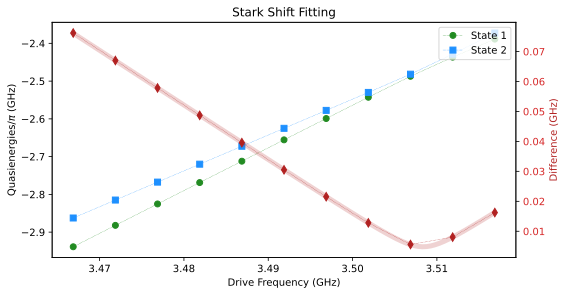

In [16]:
freqs = np.linspace(0, 0.05, 11)+base_freq

psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]


drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])

resonance_fit_res = Find_Resonance(hilbertspace.hamiltonian(), drive_op, freqs, epsilon, reference_states = [psi_e0, psi_g2])

### Getting Flat Top Time

To get the flat top time, we will use the function `get_FLZ_flattop`. This function takes in the drive parameters and calculates the phase accumulated during the ramp. The remaining required phase then gives the exact flat top time. However, it should be noted that this code assumes the ramp up and the ramp down are the same. Meaning the pulse is symmetric. For a non-symmetric pulse, the phase accumulation during the ramp up and ramp down will be different and that will need to be accounted for.

```python
psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]
H_op = hilbertspace.hamiltonian()
drive_freq = resonance_fit_res[0]
envelope_func = lambda t: Bump_Ramp_Envelope(t, ramp_time*2, ramp_time = ramp_time, k = 2)
flat_top_time = get_FLZ_flattop(H_op=H_op,
        drive_op=drive_op, 
        freq=drive_freq,
        epsilon=epsilon,
        envelope_func=envelope_func,
        ramp_time=ramp_time,
        psi0=psi_e0,
        psi1=psi_g2,
        num_t_samples=20,
        n_theta_samples=50)
```

In [43]:
psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]
H_op = hilbertspace.hamiltonian()
drive_freq = resonance_fit_res[0]
envelope_func = lambda t: Bump_Ramp_Envelope(t, ramp_time*2, ramp_time = ramp_time, k = 2)
flat_top_time = get_FLZ_flattop(H_op=H_op,
        drive_op=drive_op, 
        freq=drive_freq,
        epsilon=epsilon,
        envelope_func=envelope_func,
        ramp_time=ramp_time,  # example ramp time
        psi0=psi_e0,
        psi1=psi_g2,
        num_t_samples=20,
        n_theta_samples=50)
print("Flat top time:", flat_top_time)

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
Reference States: 100%|██████████| 2/2 [00:00<00:00, 429.28it/s]

floq_frequency: 0.0024426663275292377
θ: 3.1563191352956967, θr: 3.112139690177986
Flat top time: 202.7753073361091


## Running The Sideband

 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: overflow encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199RuntimeWarning: invalid value encountered in matmul
 /Users/gavinrockwood/.pyenv/versions/FloquetDemo/lib/python3.11/site-packages/scqubits/utils/spectrum_utils.py: 199

Final Fidelity: 99.3 %


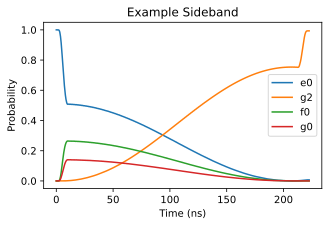

In [40]:
psi_e0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,0))]
psi_g0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,0))]
psi_f0 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((2,0))]
psi_g2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,2))]
psi_g1 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((0,1))]
psi_e2 = hilbertspace.eigensys(hilbertspace.dimension)[1][hilbertspace.dressed_index((1,2))]

e_e0 = hilbertspace.eigensys(hilbertspace.dimension)[0][hilbertspace.dressed_index((1,0))]
e_g2 = hilbertspace.eigensys(hilbertspace.dimension)[0][hilbertspace.dressed_index((0,2))]

drive_time = 2*ramp_time + flat_top_time
envelope = lambda t: epsilon * Bump_Ramp_Envelope(t, drive_time, ramp_time=ramp_time, k=2)

drive_coef = lambda t: envelope(t) * np.sin(2*np.pi*drive_freq*t)

drive_op = scq.identity_wrap(transmon.n_operator(), transmon, [transmon, oscillator])

H_T = qt.QobjEvo([hilbertspace.hamiltonian(), [drive_op, drive_coef]])

e_ops = [psi_e0*psi_e0.dag(), psi_g2*psi_g2.dag(), psi_f0*psi_f0.dag(), psi_g0*psi_g0.dag()]
times = np.arange(0, drive_time, 1/drive_freq)
#times = np.linspace(0, drive_time, int(drive_time*drive_freq))
run_res = qt.sesolve(2*np.pi*H_T, psi_e0, times, e_ops = e_ops, options = {"store_states":True, "nsteps":10000})

plt.figure(figsize=(5, 3), dpi = 150)
plt.plot(run_res.times, run_res.expect[0], label = 'e0')
plt.plot(run_res.times, run_res.expect[1], label = 'g2')
plt.plot(run_res.times, run_res.expect[2], label = 'f0')
plt.plot(run_res.times, run_res.expect[3], label = 'g0')


plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Example Sideband')
plt.legend()

print("Final Fidelity:", round(run_res.expect[1][-1], 3)*100, "%")

### Projecting the Dynamics onto the Floquet Basis
First, we will use the function `floquet_sweep` to get the Floquet modes for a range of parameters. This will allow us to see how the Floquet modes evolve as we change the parameters of our system.

```python
drive_params = []
for t in run_res.times:
    drive_params.append({"epsilon": envelope(t), "frequency": drive_freq})

floq_sweep_res = Floquet_Sweep(drive_params, hilbertspace.hamiltonian(), drive_op, sample_times = run_res.times, reference_states = [psi_e0, psi_g2])
``` 

In [44]:
drive_params = []
for t in run_res.times:
    drive_params.append({"epsilon": envelope(t), "frequency": drive_freq})

floq_sweep_res = Floquet_Sweep(drive_params, hilbertspace.hamiltonian(), drive_op, sample_times = run_res.times, reference_states = [psi_e0, psi_g2])

Reference States: 100%|██████████| 2/2 [00:00<00:00, 24.02it/s]


We can then project the dynamics onto the Floquet basis to see how the states evolve as we change the parameters of our system.

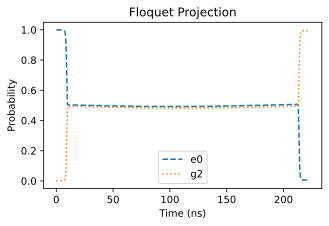

In [45]:
proj_to_e0 = [run_res.states[i].dag() * floq_sweep_res["history"][0][i] for i in range(len(run_res.states))]
proj_to_g2 = [run_res.states[i].dag() * floq_sweep_res["history"][1][i] for i in range(len(run_res.states))]

plt.figure(figsize=(5, 3), dpi = 150)
plt.plot(run_res.times, [abs(x)**2 for x in proj_to_e0], label = 'e0', linestyle = '--')
plt.plot(run_res.times, [abs(x)**2 for x in proj_to_g2], label = 'g2', linestyle = ":")

plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Floquet Projection')
plt.legend()

we see that the ramp takes us to a near $50/50$ position of the two Floquet modes. The closer the states are to this point, the higher the resulting fidelity will be!


## Docstrings

### `state_tracking`

In [8]:
print(state_tracking.__doc__)


    Tracks the evolution of quantum states for some list of states at different steps (general sweeping parameters).
    Args:
        state_history (list of list): A list where each element is a list of quantum states at a given time step.
        other_sorts (list of list, optional): Additional lists of data associated with each state, to be tracked alongside the main state history.
        reference_states (list, optional): List of reference quantum states to track. If empty, uses the first set of states in `state_history`.
    Returns:
        dict: A dictionary containing:
            - "history": List of lists of tracked quantum states for each reference state.
            - "other_sorts": List of lists of associated data for each tracked state.
            - "overlap_history": List of lists of overlap values between reference states and all states at each time step.
    


### `FloquetSweep`

In [9]:
print(Floquet_Sweep.__doc__)


    Computes Floquet modes and quasienergies for a set of drive parameters, and sorts the results according to reference states.
    Parameters
    ----------
    drive_params : list of dict
        List of dictionaries specifying drive parameters for each sweep point. Each dictionary should contain at least
        'epsilon' (drive amplitude) and 'frequency' (drive frequency).
    ham : qutip.Qobj
        The static part of the system Hamiltonian.
    drive_op : qutip.Qobj
        The operator representing the driven part of the Hamiltonian.
    reference_states : list, optional
        List of reference states used for sorting the Floquet modes. Default is an empty list.
    sample_times : list, optional
        List of times at which to sample the Floquet modes for each drive parameter. If not provided, defaults to t=0 for all.
    Returns
    -------
    sort_res : tuple
        The sorted Floquet modes and associated quasienergies, as returned by `state_tracking`.
    


### `Find_Resonance`

In [10]:
print(Find_Resonance.__doc__)


    Computes and fits the resonance in a driven quantum system using Floquet theory.
    This function sweeps over a range of Stark shifts, calculates the corresponding quasienergies
    using Floquet analysis, and fits the difference between reference states to a model function.
    Optionally, it plots the quasienergies and fitted difference.
    Parameters
    ----------
    ham : array-like or object
        The system Hamiltonian.
    drive_op : array-like or object
        The operator representing the drive.
    base_freq : float
        The base frequency of the drive (in GHz).
    epsilon : float
        The drive amplitude.
    stark_shifts : array-like
        Array of Stark shift values (in GHz) to sweep over.
    reference_states : list or array-like
        States used as references for extracting quasienergies.
    show_plot : bool, optional
        If True, displays a plot of the quasienergies and fitted difference (default is True).
    Returns
    -------
    list
  

### `get_FLZ_flattop`

In [42]:
print(get_FLZ_flattop.__doc__)


    Python conversion of the Julia get_FLZ_flattop function.
    
    Parameters:
    -----------
    H_op : qutip.Qobj
        The Hamiltonian operator
    drive_op : qutip.Qobj  
        The drive operator
    freq : float
        The drive frequency
    epsilon : float
        The drive amplitude
    envelope_func : function
        The envelope function that takes time as argument
    ramp_time : float
        The total ramp time
    psi0, psi1 : qutip.Qobj
        The two states to track
    num_t_samples : int, optional
        Number of time samples (default: 10)
    epsilons_to_sample : list, optional
        List of epsilon values to sample (if empty, will be generated)
    n_theta_samples : int, optional
        Number of theta samples for optimization (default: 100)
    dt : float, optional
        Time step (if 0, will be set to 1/freq)
        
    Returns:
    --------
    float
        The absolute value of θr/(2π*floq_frequency)
    
